# [스프린트 미션 5] Baseline — CNN 오토인코더로 문서 복원하기 (+심화: ECG 이상 탐지)

- **Part 1 (기본 미션)**: 손상된 문서 이미지를 복원하는 CNN 오토인코더
- **Part 2 (심화, 채점 제외)**: 정상 심전도만 학습해 이상 심박을 찾아내는 LSTM 오토인코더


In [1]:
import os
import random

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms.functional as TF

from PIL import Image
from torch.utils.data import Dataset, DataLoader

# device = "cuda" if torch.cuda.is_available() else "cpu"     # 맥에서 사용 불가...
device = "mps" if torch.cuda.is_available() else "cpu"
torch.manual_seed(42)
print("PyTorch:", torch.__version__, "| device:", device)

PyTorch: 2.14.0 | device: cpu


---
# Part 1. 손상된 문서 복원 — CNN 오토인코더

train(손상 이미지)과 train_cleaned(원본 이미지)를 한 쌍으로 학습합니다.
손상 이미지를 입력하면 원본에 가까운 이미지를 출력하도록 인코더-디코더를 학습시키는 구조예요.

## 1-1. 데이터 준비
Kaggle에서 데이터를 내려받습니다. 두 가지 준비가 필요해요.
1. [대회 페이지](https://www.kaggle.com/competitions/denoising-dirty-documents)에서 **Join Competition**을 눌러 규칙에 동의합니다. (동의하지 않으면 다운로드가 거부됩니다)
2. Kaggle > Settings > API에서 **Create New Token**으로 `kaggle.json`을 발급받아 두세요.

In [3]:
# kaggle.json을 업로드하세요.
# from google.colab import files
# files.upload()

!mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
!kaggle competitions download -c denoising-dirty-documents
!unzip -q denoising-dirty-documents.zip -d data
!cd data && unzip -q train.zip && unzip -q train_cleaned.zip && unzip -q test.zip
!ls data

cp: kaggle.json: No such file or directory
100%|█████████████████████████████████████| 35.7M/35.7M [00:04<00:00, 7.80MB/s]

sampleSubmission.csv.zip train                    train_cleaned.zip
test                     train.zip
test.zip                 train_cleaned


## 1-2. Dataset 구성
이미지 크기가 두 종류(420×540, 258×540)라서, 학습할 때는 **같은 위치에서 128×128 패치를 잘라** 손상/원본 쌍으로 사용합니다.
패치 단위로 학습하면 이미지 크기를 신경 쓰지 않아도 되고, 한 이미지에서 매번 다른 부분을 보게 되어 데이터가 늘어나는 효과도 있어요.

In [ ]:
# 손상된 문서 사진과 깨끗한 정답 사진에서 똑같은 위치를 128×128 크기로 잘라서 학습용 한 쌍으로 만듦

class DirtyDocsDataset(Dataset):
    """손상 이미지와 원본 이미지에서 같은 위치의 패치를 한 쌍으로 돌려줍니다."""

    def __init__(self, dirty_dir, clean_dir, crop_size=128):
        self.dirty_dir = dirty_dir                      # 손상된 이미지가 저장된 폴더 경로
        self.clean_dir = clean_dir                      # 깨끗한 이미지가 저장된 폴더 경로
        self.files = sorted(os.listdir(dirty_dir))      # 손상 이미지 폴더에 들어 있는 파일 이름을 정렬해서 저장
        self.crop_size = crop_size                      # 이미지에서 잘라낼 정사각형 영역의 한 번 길이

    def __len__(self):
        return len(self.files)                          # 데이터셋에 들어있는 전체 이미지 개수를 반환

    def __getitem__(self, idx):
        name = self.files[idx]                          # idx번째 이미지의 파일 이름을 가져옴
        dirty = Image.open(os.path.join(self.dirty_dir, name)).convert("L")     # 손상 이미지 폴더에서 idx 번째 이미지를 열고 흑백으로 변환
        clean = Image.open(os.path.join(self.clean_dir, name)).convert("L")     # 깨끗 이미지 폴더에서 같은 이름 이미지를 열고 흑백으로 변환

        # 두 이미지에서 '같은 위치'를 잘라야 하므로 crop 좌표를 직접 뽑습니다.
        # 비교하는 대상이 같아야함 위치 다른것 비교 해봐짜 뭐해..
        cs = self.crop_size                             # 잘라낼 크기
        top = random.randint(0, dirty.height - cs)      # 이미지를 자르기 시작할 세로 위치 무작위로 선택
        left = random.randint(0, dirty.width - cs)      # 이미지를 자르기 시작할 가로 위치 무작위로 선택

        # 손상 이미지에서 선택한 위치를 128 * 128로 자른 후
        # PyTorch가 처리할 수 있는 Tensor로 변환
        # (1, 128, 128), 0~1
        dirty = TF.to_tensor(TF.crop(dirty, top, left, cs, cs))
        # 깨끗한 이미지도 손상 이미지와 완전히 같은 위치로 자름  
        clean = TF.to_tensor(TF.crop(clean, top, left, cs, cs))
        # 손상 이미지 조각은 모델 입력,
        # 깨끗한 이미지 조각은 모델이 맞혀야 할 정답으로 반환
        return dirty, clean


# 손상 이미지 폴더와 깨끗한 이미지 폴더를 이용해 데이터셋 생성
train_dataset = DirtyDocsDataset("data/train", "data/train_cleaned")
# 데이터셋에서 한 번에 16개씩 꺼내도록 설정
# shuffle=True이므로 매 epoch마다 이미지 순서를 섞음
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
# __len__()이 반환하는 전체 이미지 개수 출력
print("훈련 이미지 수:", len(train_dataset))

훈련 이미지 수: 144


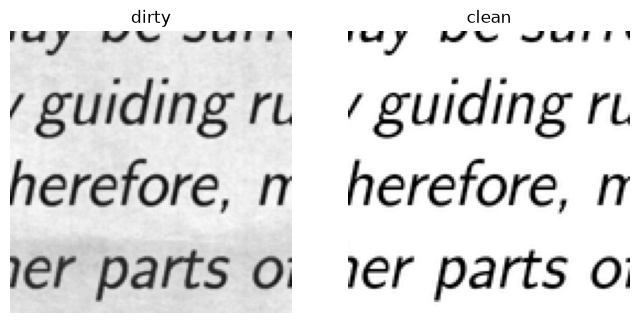

In [ ]:
# 손상/원본 쌍이 잘 만들어졌는지 확인

dirty, clean = train_dataset[0]

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
# ; : 한줄에 명령문 한줄로 사용 가능함
axes[0].imshow(dirty.squeeze(), cmap="gray"); axes[0].set_title("dirty")
axes[1].imshow(clean.squeeze(), cmap="gray"); axes[1].set_title("clean")
for ax in axes: ax.axis("off")
plt.show()

## 1-3. CNN 오토인코더 설계
`Conv2d`(stride=2)로 크기를 절반씩 줄이며 특징을 압축하고, `ConvTranspose2d`로 다시 원래 크기까지 복원합니다.
층마다 텐서 크기가 어떻게 변하는지 주석으로 적어 두세요. 인코더와 디코더의 크기가 어긋나는 문제가 이 미션에서 가장 자주 만나는 에러입니다.

In [ ]:
# 손상된 이미지 dirty를 받아서 깨끗한 이미지 clean처럼 복원하는 CNN 기반 오토인코더

class ConvDenoiser(nn.Module):
    def __init__(self):
        super().__init__()                 # nn.Modul의 기본 기능 초기화
        # Encoder:
        # 이미지의 가로 세로 길이를 줄이면서 특징 추출
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1),   # (1, 128, 128) -> (32, 64, 64)
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),  # (32, 64, 64) -> (64, 32, 32)
            nn.ReLU(),
        )
        # Decoder:
        # 추출한 특징으로부터 원래 크기의 이미지 복원
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),  # (64, 32, 32) -> (32, 64, 64)
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, kernel_size=4, stride=2, padding=1),   # (32, 64, 64) -> (1, 128, 128)
            nn.Sigmoid(),  # 픽셀 값을 0~1 범위로
        )

    def forward(self, x):
        # 반.환. 추출한 특징을 Decoder에 넣어 깨끗한 이미지로 복원(손상 이미지를 Encoder에 넣어 특징 추출)
        return self.decoder(self.encoder(x))


# 모델 생성 후 CPU 또는 GPU로 이동
model = ConvDenoiser().to(device)
# 모델이 어떤 층으로 구성되어 있는지 확인
print(model)

ConvDenoiser(
  (encoder): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(32, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): Sigmoid()
  )
)


In [ ]:
# 손상 이미지 dirty를 모델에 넣고, 모델이 복원한 restored와 깨끗한 정답 clean의 차이를 계산하여 모델의 가중치를 수정

criterion = nn.MSELoss()                                    # 손실함수 설정 - MSE
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)   # Optimizer 설정 - 가중치 수정 역할

EPOCHS = 30
for epoch in range(EPOCHS):
    # 학습 모드
    model.train()
    # epoch 손실 초기화
    epoch_loss = 0.0

    # 배치 단위 반복 : batch_size=16
    for dirty, clean in train_loader:
        # 데이터를 CPU 또는 GPU로 이동
        dirty, clean = dirty.to(device), clean.to(device)

        # 이전 기울기 초기화
        optimizer.zero_grad()

        # 순전파
        restored = model(dirty)

        # 손실 계산
        loss = criterion(restored, clean)

        # 역전파 : 새로운 기울기 계산
        loss.backward()

        # 역전파에서 계산한 기울기를 사용해 가중치 수정
        optimizer.step()

        # 배치 손실 누적 : 왜 곱하나?? -> 마지막 배치가 4개라서.. 마지막에 전체 이미지 개수로 나누면 이미지 개수를 고려한 평균을 구할 수 있으!!
        epoch_loss += loss.item() * len(dirty)
        
    if (epoch + 1) % 5 == 0:
        # 평균 손실 출력 : 에폭 번호 세 자리에 맞춰 출력
        print(f"epoch {epoch + 1:3d} | loss {epoch_loss / len(train_dataset):.5f}")

epoch   5 | loss 0.00659
epoch  10 | loss 0.00621
epoch  15 | loss 0.00547
epoch  20 | loss 0.00512
epoch  25 | loss 0.00469
epoch  30 | loss 0.00430


## 1-4. 전체 이미지 복원과 평가
학습은 128×128 패치로 했지만, 합성곱 모델은 입력 크기가 달라도 동작합니다.
다만 stride=2 층을 두 번 지나므로 가로/세로가 4의 배수여야 해요. 4의 배수가 아닌 이미지(258×540)는 가장자리를 패딩했다가 복원 후 잘라냅니다.

RMSE: 0.0474


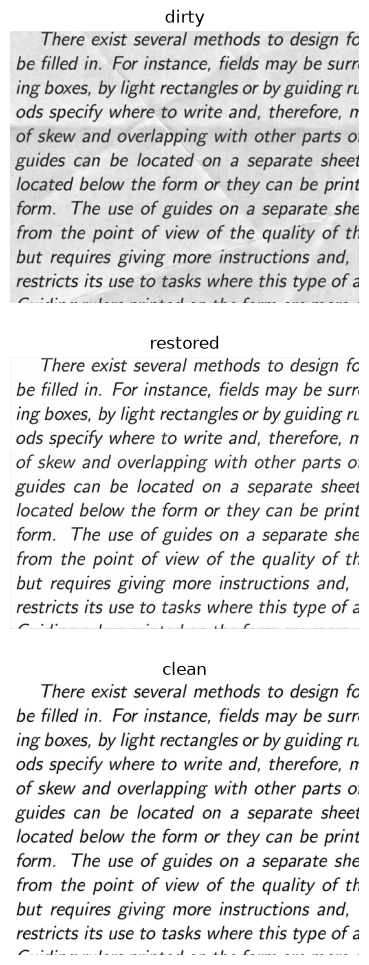

In [ ]:
# 이미지 한 장 전체를 넣어 복원 결과를 확인하는 코드

def denoise_full_image(model, img_tensor, multiple=4):
    """크기가 4의 배수가 아니면 오른쪽/아래를 패딩한 뒤 복원하고, 원래 크기로 되돌립니다."""
    # 크기가 127처럼 애매하면 축소 과정에서 반올림 문제가 생겨서 출력 크기가 입력 크기와 달라질 수 있음

    # 이미지 모양 가져오기
    # 채널이 _ 인 이유 : 받기는 하지만 이후에 사용하지 않기에....
    _, h, w = img_tensor.shape

    # 높이, 너비에 필요한 패딩 계산
    pad_h = (multiple - h % multiple) % multiple
    pad_w = (multiple - w % multiple) % multiple

    # 배치 차원 추가 후 패딩
    #    4개의 배치 차원이 필요해서 차원 추가  이미지 오른쪽 아래로 패딩 추가  패딩 영역을 단순히 0으로 채우는게 아닐 이미지 가장자리 내용을 거울처럼 반사해서 채움
    x = F.pad(img_tensor.unsqueeze(0), (0, pad_w, 0, pad_h), mode="reflect")

    # 평가 모드
    model.eval()
    # 기울기 계산 끄기 : 모델 학습이 목적이 아닌 보권 결과만 확인 -> 메모리 적게 사용 / 계산 속도 빨라짐 / 실수로 학습용 계산 그래프 만드는 것 방지
    with torch.no_grad():
        # 전체 이미지 복원
        out = model(x.to(device)).cpu()
    # 패딩 제거 : 패딩헤서 복우너 후 추가했던 영역 잘라내고 원래 크기로 되돌리기
    return out[0, :, :h, :w]


# 훈련 이미지 하나를 통째로 복원해 봅니다.
# 첫번째 파일 이름 가져오기
name = train_dataset.files[0]

# 손상된, 깨끗한 전체 이미지 불러오기
dirty_full = TF.to_tensor(Image.open(f"data/train/{name}").convert("L"))
clean_full = TF.to_tensor(Image.open(f"data/train_cleaned/{name}").convert("L"))

# 전체 이미지 복원
restored_full = denoise_full_image(model, dirty_full)

# RMSE 계산 : 평균 제곱 오차의 제곱근
rmse = torch.sqrt(((restored_full - clean_full) ** 2).mean())
# 출력
print(f"RMSE: {rmse:.4f}")

# 세로로 그림 세 개 만들기
fig, axes = plt.subplots(3, 1, figsize=(10, 12))
for ax, img, title in zip(axes, [dirty_full, restored_full, clean_full], ["dirty", "restored", "clean"]):
    # 흑백 이미지 출력                          제목 설정              좌표 눈금 숨기기
    ax.imshow(img.squeeze(), cmap="gray"); ax.set_title(title); ax.axis("off")
plt.show()

## Baseline 얼추 파악을 했으니 요구사항과 같이 개선해보자!!!!!

## 1-5. Baseline은 얕은 오토인코더라 흐릿한 얼룩 정도만 지웁니다. 아래 방향들을 실험하며 복원 품질을 높여 보세요.

- ### 각 진행 가이드 리스트의 내용에 대해 조사 후 코드 들어가기 전에 순서를 맞춰볼 예정

    출처는 거의 GPT 이긴 하지만.. 그래도 열심히 찾아보자..

### 1-5-1. 인코더/디코더를 더 깊게 쌓거나 채널 수를 늘려 보기 (BatchNorm 추가 포함)

- #### 1-3. CNN 오토인코더 설계에서 추가적으로 깊게 쌓거나 채널 수 늘리기 : Hidden Layer 층을 몇개 더 추가해서 진행하기

- #### 근데.. BatchNorm 추가 포함... 이게 뭔지 알아보자!!!

    BatchNorm 이란??

    - 데이터 정규화 및 스케일링
    
    사용 순서 : **Linear/Conv 레이어 → BatchNorm → 활성화 함수(ReLU 등)**

    주의할 점
    
    - PyTorch에서는 **nn.BatchNorm1d(선형 레이어용)** 또는 **nn.BatchNorm2d(이미지/Conv 레이어용)** 를 사용합니다. 

        -> 우리는 이미지/Conv 레이어용 이므로 **nn.BatchNorm2d** 사용
        
    - **bias=False** 설정 권장: Conv2d 바로 뒤에 BatchNorm2d가 오면, BatchNorm의 정규화 과정에서 Conv의 bias(편향) 성분이 상쇄됩니다. 따라서 메모리 절약을 위해 nn.Conv2d(..., bias=False)로 설정하는 것이 좋습니다.

    - **출력층 제외** : Decoder의 맨 마지막 layer에는 BatchNorm을 쓰지 않습니다. 데이터 고유의 스케일(예: 0~1 사이의 픽셀 값)을 그대로 복원해야 하기 때문이다.

    - **Mini-batch 크기** : BatchNorm은 배치의 평균과 분산을 이용하므로, Batch size가 지나치게 작으면(예: 2 또는 4) 학습이 불안정해질 수 있습니다. 최소 16 이상을 권장합니다.

### 1-5-2. 인코더의 중간 출력을 디코더에 이어 주는 스킵 커넥션 추가해 보기

- #### 1-3. CNN 오토인코더 설계에서 함수(?) 처럼 각 hidden layer 마다 이름 지정..?

- #### 스킵 커넥션이 무엇인지... 찾아보자!!!!!

    Skip Connection 이란??
    
    - 인코더의 세밀한 고해상도 공간 정보를 디코더로 직접 전달해 데이터 복원 성능 극대화하는 기법

    역할 및 효과
        
    - **정보 손실 보완** : 인코더 과정에서 풀링(Pooling)이나 스트라이드 컨볼루션(Stride Convolution)을 거치며 사라지는 미세한 위치 및 경계(Spatial) 정보를 디코더에 직접 전달합니다.
    
    - **복원 품질 향성** : 단순 오토인코더 대비 노이즈 제거(Denoising), 이미지 복원(Inpainting), 세분화(Segmentation) 작업에서 구조와 디테일 보존 능력이 크게 향상됩니다.

    - **기울기 소실 완화** : 역전파(Backpropagation) 시 기울기가 손실되지 않고 앞쪽 레이어로 원활하게 전달되도록 돕습니다.

    강사님께서 주신 힌트

    >> def forward <- 여기서 아래 코드 잘 넣어보셈
    >>
    >>  **torch.cat**
    >> 
    >> **([d2, e1], dim=1)**
    >> 
    >> **d2 + e1**


출처

https://www.kci.go.kr/kciportal/landing/article.kci?arti_id=ART002660552

https://railly-linker.tistory.com/184


### 1-5-3. 좌우 반전, 밝기 조절 같은 데이터 증강 적용해 보기

- #### 1-2. Dataset 구성 할때 데이터 증강을 적용하면 되지 않을까??

- #### 근데.. 데이터 증강하면 뭐가 좋을까..?

    좌우 반전(Horizontal Flip)이나 밝기 조절(Brightness Adjustment) 같은 데이터 증강(Data Augmentation)을 적용하면 좋은 점

    -> 모델의 강건함(Robustness)을 키우는 좋은 방법


    주의할 점

    - 기하학적 변형(좌우 반전, 회전, 크롭): 오토인코더 학습 시 반드시 입력과 정답 이미지에 동일하게 적용해야 합니다.

    - 픽셀 값 변형(밝기, 대비, 노이즈 추가): Denoising Autoencoder를 원한다면 입력에만 적용하고, 일반적인 데이터 증강이 목적이라면 둘 다 적용해야 합니다.

### 1-5-4. 검증 세트를 나눠 과적합 여부를 확인하고, test 이미지 복원 결과 비교하기

- #### 1-2. Dataset 구성 과정에서 train 데이터 안에 학습용과 검증용을 나눠서 진행하면 될 듯..?!
    - train 데이터가 144장이니까 20% 정도 검증용으로 따로 빼야겠다 ( 검증용 : 약 29장 )

    
- #### 1-4. 전체 이미지 복원과 평가 과정에서 검증 안했을때와 검증 했을때 결과 비교해보자?!?!

### 1-5-5. 평가 지표에 PSNR을 추가하고, 복원이 잘 안 되는 손상 유형 분석하기

- #### 1-4. 전체 이미지 복원과 평가 과정에서 진행하면 될거 같은...

- #### 근데 PSNR이 뭐지요..?

    PSNR (Peak Signal-to-Noise Ratio, 신호 대 잡음비)

    - 신호는 원본 이미지의 정보, 잡음은 원본과 복원본의 차이를 의미

    - 모델이 완벽하면 잡음이 0이고, 엉터리로 복원하면 잡음이 커진다. 잡음이 작을수록(복원이 정확할수록) 비율이 커진다.

        -> PSNR은 클수록 좋다!!!!!

    - 일반적으로 30~40 dB 이상이면 양호한 복원 품질로 평가

## 1-6. 전체 순서 및 실험 진행 단계

|  단계 | 실험 내용             | 목적                             | 비교 내용                        |
| --: | -------------------- | ------------------------------ | ------------------------------ |
| 0단계 | 세팅                 |                                |                                |
| 1단계 | 훈련·검증 데이터 분리    | 모든 모델을 같은 조건에서 공정하게 평가  | 학습 80%, 검증 20%로 고정         |
| 2단계 | Baseline 결과 측정    | 개선 전 기준 성능 기록               | 검증 RMSE·PSNR                 |
| 3단계 | 깊은 모델 + BatchNorm | 특징 추출 능력과 학습 안정성 개선       | Baseline과 RMSE·PSNR 비교       |
| 4단계 | 스킵 커넥션 추가        | 글자와 윤곽 같은 세부 정보 보존        | 2단계 모델과 RMSE·PSNR 비교       |
| 5단계 | 데이터 증강 추가        | 처음 보는 손상 이미지에 대한 일반화 개선 | 3단계 모델과 RMSE·PSNR 비교       |
| 6단계 | 전체 실험 결과 비교      | 성능이 가장 좋은 최종 모델 선택       | 모든 모델의 RMSE·PSNR 결과표       |
| 7단계 | Test 이미지 복원       | 최종 모델의 실제 복원 결과 확인       | 손상 이미지와 복원 이미지 시각 비교     |
| 8단계 | 실패 사례 분석          | 복원이 어려운 손상 유형과 한계 확인    | 복원 전후 PSNR과 절대 오차 이미지 분석 |


## 1-7. 위의 진행 순서를 기반으로 코드 재구성

### 1-7-0. 세팅

In [3]:
import os
import random

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms.functional as TF

from PIL import Image
from torch.utils.data import Dataset, DataLoader

# device = "cuda" if torch.cuda.is_available() else "cpu"     # 맥에서 사용 불가...
device = "mps" if torch.cuda.is_available() else "cpu"

RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

print("PyTorch:", torch.__version__, "| device:", device)

PyTorch: 2.14.0 | device: cpu


### 1-7-1. Dataset 구성 + 훈련·검증 데이터 고정 분리



### 1-7-2. Baseline 학습 및 평가 + 기준 RMSE·PSNR 기록

### 1-7-3. 깊은 모델 + BatchNorm

### 1-7-4. 스킵 커넥션 추가

### 1-7-5. 데이터 증강 추가

### 1-7-6. 실험 결과 비교 및 최종 모델 선택

### 1-7-7. Test 이미지 복원

### 1-7-8. 실패 사례 분석

---
# Part 2. (심화) 심전도 이상 탐지 — LSTM 오토인코더

심화 문제는 채점에 포함되지 않아요. 여유가 될 때 도전해 봅시다.

이번에는 순서가 있는 데이터입니다. **정상 심전도(ECG) 신호만으로** LSTM 오토인코더를 학습시킵니다.
정상 패턴만 배운 모델은 이상 신호를 제대로 복원하지 못하므로, **복원 오차가 큰 신호를 이상 심박으로 판정**할 수 있어요.

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv("http://storage.googleapis.com/download.tensorflow.org/data/ecg.csv", header=None)
data = df.iloc[:, :-1].values.astype("float32")  # (4998, 140) — 신호 하나당 140 타임스텝
labels = df.iloc[:, -1].values.astype(int)       # 1: 정상, 0: 이상

X_train, X_test, y_train, y_test = train_test_split(
    data, labels, test_size=0.2, random_state=42, stratify=labels
)

# 훈련 데이터 기준으로 0~1 정규화
mn, mx = X_train.min(), X_train.max()
X_train = (X_train - mn) / (mx - mn)
X_test = (X_test - mn) / (mx - mn)

# 핵심: 정상 신호만 골라 학습 세트를 만듭니다.
X_train_normal = X_train[y_train == 1]
print("전체 훈련:", X_train.shape, "| 정상만:", X_train_normal.shape, "| 테스트:", X_test.shape)

In [ ]:
# 정상 신호와 이상 신호를 눈으로 비교해 봅시다.
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
axes[0].plot(X_train[y_train == 1][0]); axes[0].set_title("normal")
axes[1].plot(X_train[y_train == 0][0]); axes[1].set_title("anomaly")
plt.show()

## 2-1. LSTM 오토인코더 설계
인코더 LSTM의 **마지막 hidden state**가 신호 전체를 요약한 잠재 벡터가 됩니다.
디코더는 이 벡터를 타임스텝 수만큼 반복해 입력받아, 원래 신호를 되살려 냅니다.

In [ ]:
class LSTMAutoencoder(nn.Module):
    def __init__(self, seq_len=140, n_features=1, hidden_size=64):
        super().__init__()
        self.seq_len = seq_len
        self.encoder = nn.LSTM(n_features, hidden_size, batch_first=True)
        self.decoder = nn.LSTM(hidden_size, hidden_size, batch_first=True)
        self.output_layer = nn.Linear(hidden_size, n_features)

    def forward(self, x):
        # x: (batch, 140, 1)
        _, (h, _) = self.encoder(x)                          # h: (1, batch, 64) — 신호 전체의 요약
        z = h[-1]                                            # (batch, 64)
        dec_in = z.unsqueeze(1).repeat(1, self.seq_len, 1)   # (batch, 140, 64)
        out, _ = self.decoder(dec_in)                        # (batch, 140, 64)
        return self.output_layer(out)                        # (batch, 140, 1)


ae = LSTMAutoencoder().to(device)
print(ae)

In [ ]:
from torch.utils.data import TensorDataset, DataLoader

X_train_normal_t = torch.tensor(X_train_normal).unsqueeze(-1)  # (N, 140, 1)
normal_loader = DataLoader(TensorDataset(X_train_normal_t), batch_size=128, shuffle=True)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(ae.parameters(), lr=1e-3)

EPOCHS = 100
for epoch in range(EPOCHS):
    ae.train()
    epoch_loss = 0.0
    for (xb,) in normal_loader:
        xb = xb.to(device)
        optimizer.zero_grad()
        loss = criterion(ae(xb), xb)  # 입력을 그대로 복원하도록 학습
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(xb)
    if (epoch + 1) % 20 == 0:
        print(f"epoch {epoch + 1:3d} | loss {epoch_loss / len(X_train_normal_t):.5f}")

## 2-2. 복원 오차 분포와 임계값
정상 훈련 신호의 복원 오차 분포를 기준으로 임계값을 정합니다.
Baseline은 `평균 + 2×표준편차`를 사용했지만, 백분위수(예: 95%) 등 다른 기준도 실험해 보세요.

In [ ]:
def recon_errors(model, X):
    """신호별 복원 오차(MSE)를 계산합니다."""
    model.eval()
    x = torch.tensor(X).unsqueeze(-1)
    with torch.no_grad():
        pred = model(x.to(device)).cpu()
    return ((pred - x) ** 2).mean(dim=(1, 2)).numpy()


train_errors = recon_errors(ae, X_train_normal)
threshold = train_errors.mean() + 2 * train_errors.std()
print(f"임계값: {threshold:.5f}")

# 테스트 세트에서 정상/이상의 오차 분포가 갈라지는지 확인해 봅시다.
test_errors = recon_errors(ae, X_test)
plt.figure(figsize=(8, 4))
plt.hist(test_errors[y_test == 1], bins=50, alpha=0.6, label="normal")
plt.hist(test_errors[y_test == 0], bins=50, alpha=0.6, label="anomaly")
plt.axvline(threshold, color="red", linestyle="--", label="threshold")
plt.xlabel("reconstruction error"); plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import classification_report

# 오차가 임계값보다 크면 이상(0), 작으면 정상(1)으로 판정합니다.
y_pred = (test_errors <= threshold).astype(int)
print(classification_report(y_test, y_pred, target_names=["anomaly(0)", "normal(1)"], digits=3))

In [ ]:
# 모델이 이상 신호를 '못' 복원하는 모습을 직접 확인해 봅시다.
def plot_reconstruction(model, signal, title):
    x = torch.tensor(signal).reshape(1, -1, 1)
    with torch.no_grad():
        pred = model(x.to(device)).cpu().squeeze()
    plt.plot(signal, label="original")
    plt.plot(pred, label="reconstructed")
    plt.fill_between(range(len(signal)), signal, pred, alpha=0.3)
    plt.title(title); plt.legend()


plt.figure(figsize=(12, 3.5))
plt.subplot(1, 2, 1); plot_reconstruction(ae, X_test[y_test == 1][0], "normal")
plt.subplot(1, 2, 2); plot_reconstruction(ae, X_test[y_test == 0][0], "anomaly")
plt.show()

## 2-3. 더 실험해 볼 것들
- 임계값 기준을 바꿔 보며 Precision과 Recall이 어떻게 움직이는지 관찰하기
- hidden size, 층 수를 조절하거나 LSTM을 GRU로 바꿔 비교하기
- 인코더를 양방향(bidirectional)으로 바꾸면 복원 품질이 달라지는지 확인하기

기본 미션과 심화 문제 모두 하나의 노트북에 담아 `05_{팀명}_{성함}.ipynb`로 제출해 주세요.